In [2]:
from spectral_spatial_simulation import LookupTableWET
from prettyconsole import Console
from file import Configurator
import file
from tools import JupyterPlotManager

%matplotlib ipympl

In [3]:
config_file_name = "paths_09012026.json"
configurator = Configurator(path_folder="../config/",
                            file_name=config_file_name)
configurator.load()

# Load and interpolate the maps

In [4]:
loaded_B1_map = file.ParameterMaps(configurator=configurator, map_type_name="B1").load_file().to_working_volume().maps[0]
target_size = loaded_B1_map.values.shape
target_gpu_interpolation = 2
loaded_B0_map = file.ParameterMaps(configurator=configurator, map_type_name="B0").load_file().to_working_volume().maps[0].interpolate(target_size=target_size, order=1, device="gpu", target_gpu=target_gpu_interpolation)
loaded_T1_map = file.ParameterMaps(configurator=configurator, map_type_name="T1").load_file().to_working_volume().maps[0].interpolate(target_size=target_size, order=1, device="gpu", target_gpu=target_gpu_interpolation)

[  1  ][  info   ] >> Maps object: The provided path points to a file                                                      
[  2  ][  error  ] >> Could not convert loaded unit 'unknown' to pint unit. Therefore, assigned 'dimensionless'!           
[  3  ][  info   ] >> Loading nii file for map type B1                                                                     
[  4  ][ success ] >> NaNs are NOT present!                                                                                
[  5  ][ success ] ---v  (collected several lines)                      
                      Loaded nii map: B1Map_TargetRes.nii | Shape: (180, 180, 109) | Values range: [-19.237, 102.543] | Unit: None | Unique values: 334682
                      
[  6  ][ success ] ---v                       
                      Created 4D volume of metabolite maps: ['B1']. 
                       Map type: ....... B1 
                       Unit: ........... None 
                       Shape: .......... (1, 

# Check maps for NaNs

In [5]:
loaded_B1_map.check_nan().enforce_positive_values(convert_negative=True, convert_zeros=True)

loaded_B0_map.check_nan()
loaded_T1_map.check_nan()

[ 19  ][ success ] >> NaNs are NOT present!                                                                                
[ 20  ][ success ] >> Converted negative and zero values to eps: 2.220446049250313e-16                                     
[ 21  ][ success ] >> NaNs are NOT present!                                                                                
[ 22  ][ success ] >> NaNs are NOT present!                                                                                


# Plot the loaded maps

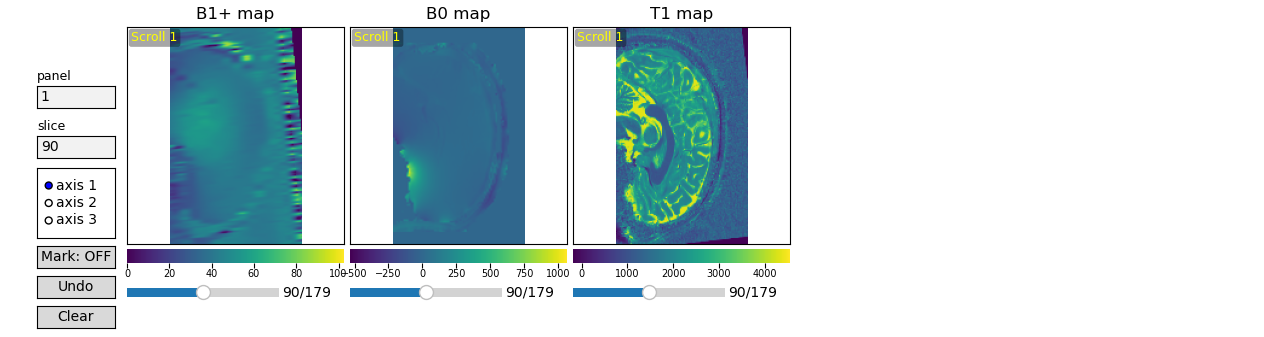

(<Figure size 1264x337 with 17 Axes>,
 array([[<Axes: title={'center': 'B1+ map'}>,
         <Axes: title={'center': 'B0 map'}>,
         <Axes: title={'center': 'T1 map'}>, <Axes: >, <Axes: >]],
       dtype=object),
 {'layout_all': <function tools.JupyterPlotManager.volume_grid_viewer.<locals>.layout_all()>,
  'selected_panel': [0],
  'axis_per_panel': [0, 0, 0],
  'sliders': {0: <matplotlib.widgets.Slider at 0x7f787817ed70>,
   1: <matplotlib.widgets.Slider at 0x7f7878027520>,
   2: <matplotlib.widgets.Slider at 0x7f78780d58a0>},
  'images': {0: <matplotlib.image.AxesImage at 0x7f7881fc31c0>,
   1: <matplotlib.image.AxesImage at 0x7f78781e8ac0>,
   2: <matplotlib.image.AxesImage at 0x7f7878084e80>},
  'markers': [],
  'marking_enabled': [False],
  'click_cid': 44,
  'key_cid': 45,
  'marker_counts': {},
  'slider_tick_lines': {}})

In [6]:
JupyterPlotManager.volume_grid_viewer(
    vols=[loaded_B1_map.values, loaded_B0_map.values, loaded_T1_map.values],
    titles=["B1+ map", "B0 map", "T1 map",],
    rows=1, cols=5, cmap="viridis")

# Create Lookup Table

In [7]:
# Fixed input variables for the Bloch Simulation
TR = 600   # [ms]
TE = 0     # [ms]
T2 = 250   # [ms]
flip_angle_excitation = 47.0           # [°] # Why exactly this flip angle?
flip_angles_WET = [89.2, 83.4, 160.8]  # [°] Why exactly this flip angles?
time_gaps_WET = [30, 30, 30]           # [ms]

# Variables containing range for generating the dictionary
T1_step_size = 50      # [ms]
T1_range = [300, 5000] # [ms]

# What is this?
B1_scales_inhomogeneity = [1e-10,3] # Maybe this is the possible range due to the inhomogeneities?
B1_scales_gauss = [0.01, 1]         # Maybe this is the possible range of the gauss excitation pulse?
B1_scales_inhomogeneity_step_size = 0.05
B1_scales_gauss_step_size=0.05


off_resonance=0

# To simulate the evolution of M = (Mx, My, Mz) of a spin system during a WET sequence + final excitation pulse.
lookup_table_WET_test = LookupTableWET(T1_range=T1_range,                      #### TODO: describe each of them
                                       T1_step_size=T1_step_size,
                                       T2=T2,
                                       B1_scales_inhomogeneity=B1_scales_inhomogeneity, # TODO
                                       B1_scales_gauss=B1_scales_gauss,
                                       B1_scales_inhomogeneity_step_size=B1_scales_inhomogeneity_step_size,
                                       B1_scales_gauss_step_size=B1_scales_gauss_step_size,
                                       TR=TR,
                                       TE=TE, # TODO -> why 0???
                                       flip_angle_excitation_degree=flip_angle_excitation,
                                       flip_angles_WET_degree=flip_angles_WET,
                                       time_gaps_WET=time_gaps_WET,
                                       off_resonance=off_resonance)

lookup_table_WET_test.create()

[ 23  ][  info   ] ---v                       
                      Start creating the Lookup Table for WET (water suppression enhanced through T1 effects)
                       => Axis 1: B1 scale | Resolution:  0.050 | Range:  0.000: 3.000
                       => Axis 2: T1/TR    | Resolution:  0.083 | Range:  0.500: 8.333


100%|███████████████████████████████████████████| 95/95 [00:05<00:00, 17.94it/s]

[ 24  ][ success ] >> Created WET lookup table with 5795 entries. Values Range: [2.8850151969148033e-05, 1.0]              


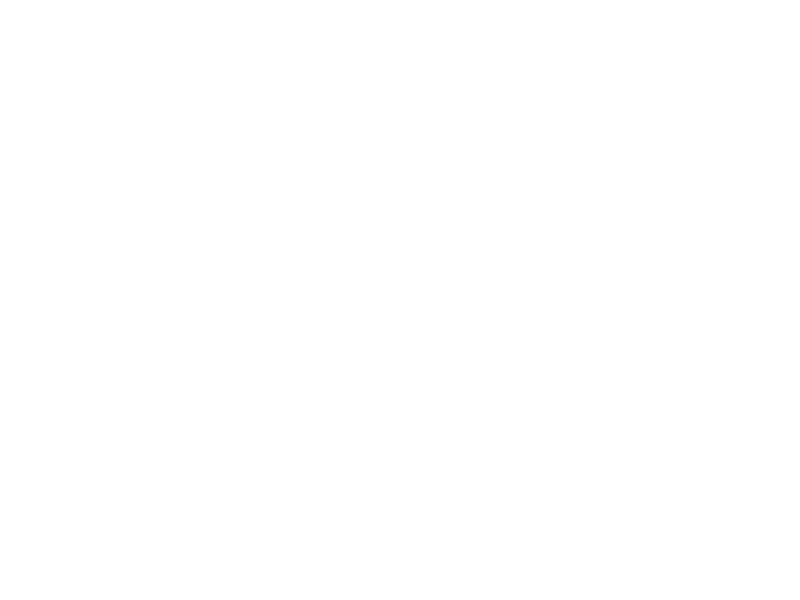

In [8]:
lookup_table_WET_test.plot()